#Tech Challenge - Fase 2 - Classificação da qualidade de vinhos com ML

O objetivo do segundo Tech Challenge é prever a qualidade do vinho a partir de um modelo de classificação. O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de prever essa classificação a partir das variáveis disponívels. Para simplificar o problema, a variável de qualidade deverá ser transformada em uma classificação binária.

**Sobre o dataset**

*   **Acidez fixa(Fixed Acidity)**:Representa os ácidos naturais do vinho que não evaporam facilmente, como os ácidos tartárico, málico e cítrico. Influencia o frescor, sabor equilíbrio da bebida.
*   **Acides volátil (Volatile Acidity):** quantidade de ácido acético presente no vinho, niveis altos podem gerar sabor semelhante ao vinagre.
*   **Ácido cítrico (Citric Acid):** encontrado em pequenas quantidades, pode contribuir para a sensação de frescor e sabor do vinho.
*   **Açúcar residual (Residual Sugar):** quantidade de açúcar remanescente após o encerramento da fermentação alcoólica.
*   **Cloretos (Chlorides):** representam a concentração de sais presentes no vinho, normalmente associados ao cloreto de sódio.
*   **Dióxido de enxofre livre (Free Sulfur Dioxide):** fração livre do dióxido de enxofre disponível para atuar na preservação e proteção contra oxidação.
*   **Dióxido de enxofre total (Total Sulfur Dioxide):** soma do dióxido de enxofre livre e do ligado a outros compostos.
*   **Densidade (Density):** medida da densidade do vinho, influenciada principalmente por açúcar e álcool presentes.
*   **pH:** medida química relacionada ao nível de acidez do vinhos
*   **Sulfatos (Sulphates):** compostos relacionados ao sulfato de potássio presentes no vinho, associados à preservação e características sensoriais.
*   **Teor Alcoólico (Alcohol):** percentual de álcool por volume gerado durante a fermentação.
*   **Qualidade do vinho (Quality):** variável de saída baseada em avaliações sensoriais, representada por uma nota entre 0 e 10 atribuída por especialistas






Começarmos a análise importando as bibliotecas para fazer uma análise básica dos dados, enteder seu comportamento, outliers, possíveis correlações e antes de tudo tratar a base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# Substitui espaços por underscores nos nomes das colunas
df.columns = df.columns.str.replace(' ', '_')
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
#Retirando a coluna "Id"
df = df.drop(columns='Id')
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
#Verificando o tamanho da nossa base de dados
df.shape

(1143, 12)

In [6]:
#Verificação de valore nulos
df.isnull().sum()

,0
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
pH,0
sulphates,0


Até o momento:
*   Foram retirados os espaços dos cabeçalhos para facilitar o codigo
*   Retirado a coluna 'Id', já que não tem valor para a análise
*   Verificamos que o tamanho da nossa base é de 1143 amostras de vinho e são 12 características totais que serão visualizadas na análise.

A seguir, verificaremos os tipos de dados e faremos correção se necessário, além de verificar o comportamento das caracterísitcas afim de identificar outliers.



In [7]:
#Verificação dos tipos de dados:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1143 non-null   float64
 1   volatile_acidity      1143 non-null   float64
 2   citric_acid           1143 non-null   float64
 3   residual_sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free_sulfur_dioxide   1143 non-null   float64
 6   total_sulfur_dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [8]:
#Verificação estatística da base de dados
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1143.0,8.31,1.75,4.60,7.10,7.90,9.10,15.90
volatile_acidity,1143.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric_acid,1143.0,0.27,0.20,0.00,0.09,0.25,0.42,1.00
residual_sugar,1143.0,2.53,1.36,0.90,1.90,2.20,2.60,15.50
chlorides,1143.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free_sulfur_dioxide,1143.0,15.62,10.25,1.00,7.00,13.00,21.00,68.00
total_sulfur_dioxide,1143.0,45.91,32.78,6.00,21.00,37.00,61.00,289.00
density,1143.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1143.0,3.31,0.16,2.74,3.20,3.31,3.40,4.01
sulphates,1143.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


Na verificação dos tipos de dados, vemos que apenas a qualidade do vinho é inteiro, o resto é real.

Já na análise estatística, notamos que algumas variáveis possuem outliers, podemos inferir isso baseado nos valores de quartis, média e os valores mínimo e máximos. Alguns exemplos, são: Acidez fixa, Açúcar residual, Teor Alcoólico e Dióxido de Enxofre livre. Mas para termos certeza, veremos as interpretações gráficas das variáveis, utilizando histograma e boxplot para cada variável.

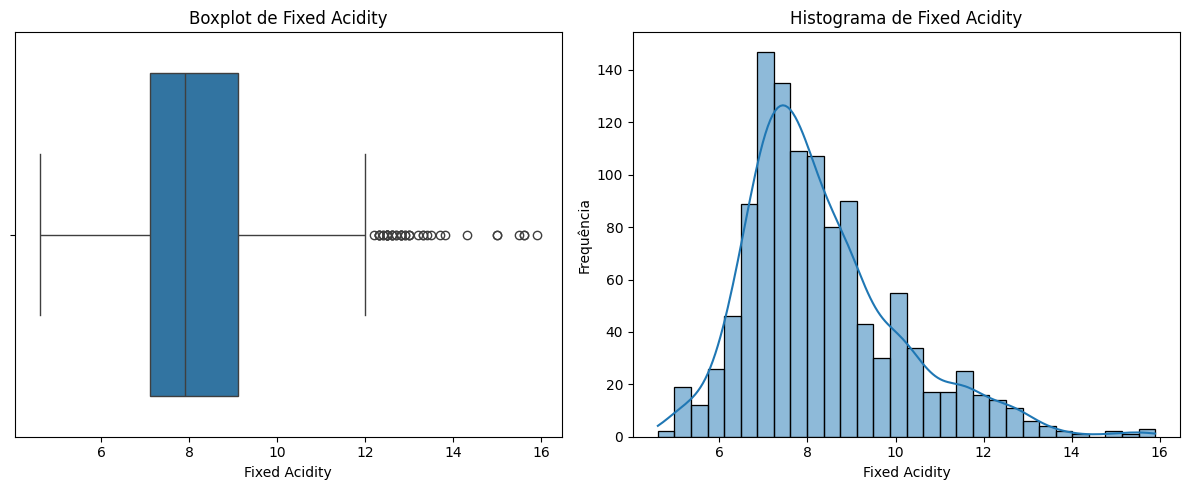

In [9]:
#Comportamento/Destribuição da Acidez Fixa
feature_name = 'fixed_acidity' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

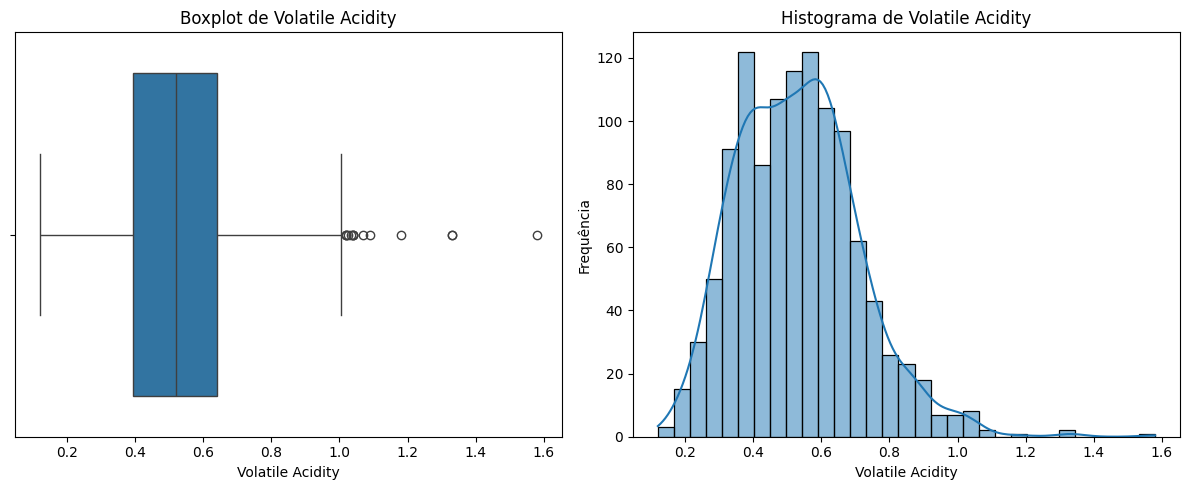

In [10]:
#Comportamento/Destribuição da Acidez Volátil
feature_name = 'volatile_acidity' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

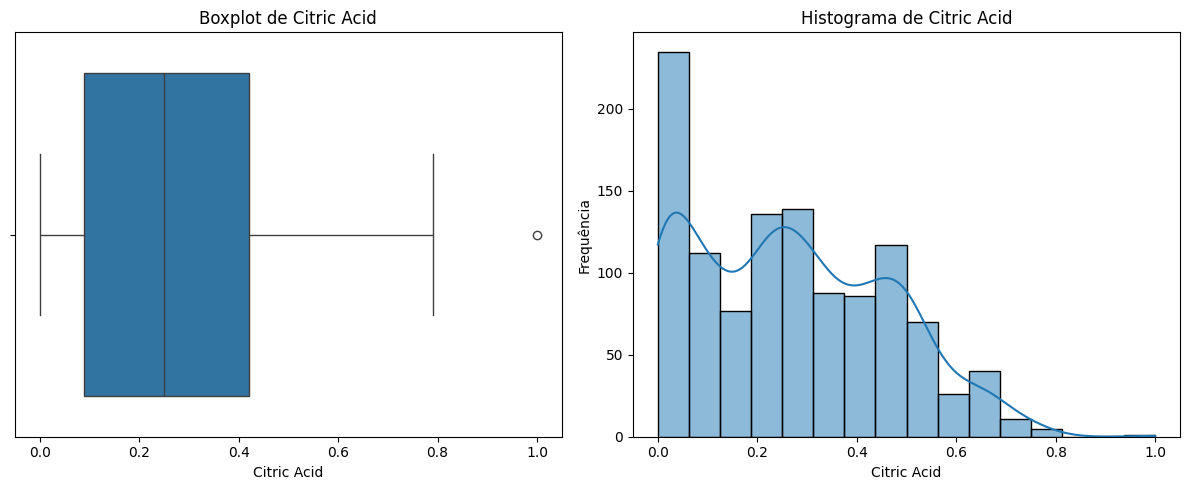

In [11]:
#Comportamento/Destribuição da Acidez Cítrica
feature_name = 'citric_acid' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

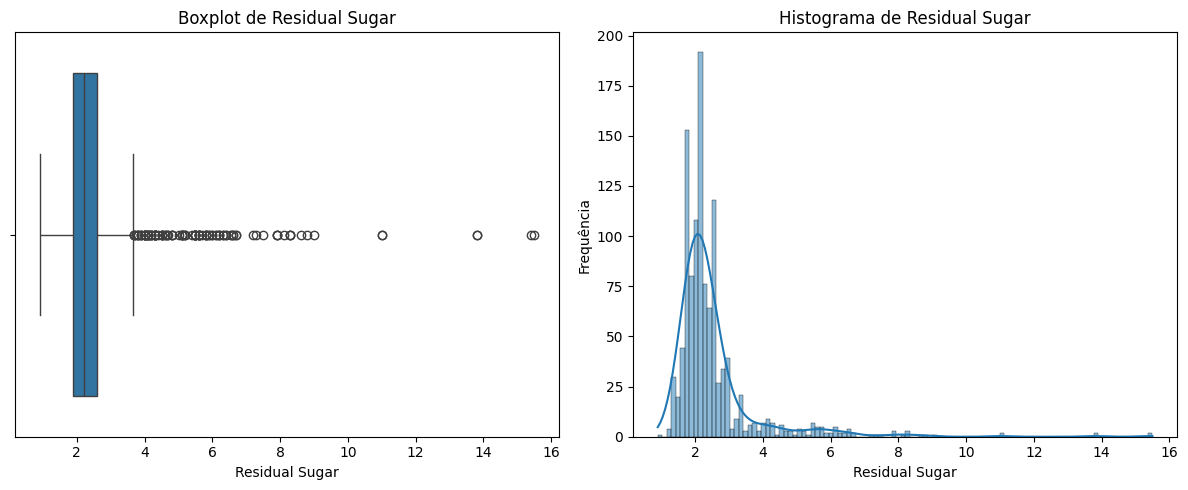

In [12]:
#Comportamento/Destribuição do Açúcar Residual
feature_name = 'residual_sugar' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

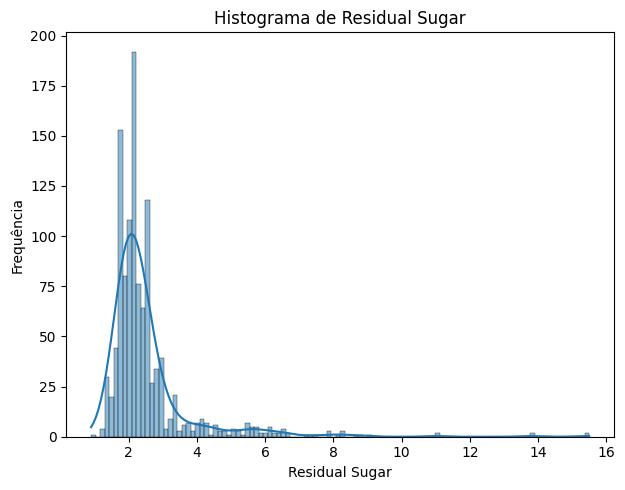

In [33]:
#Comportamento/Destribuição do Açúcar Residual
feature_name = 'residual_sugar' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

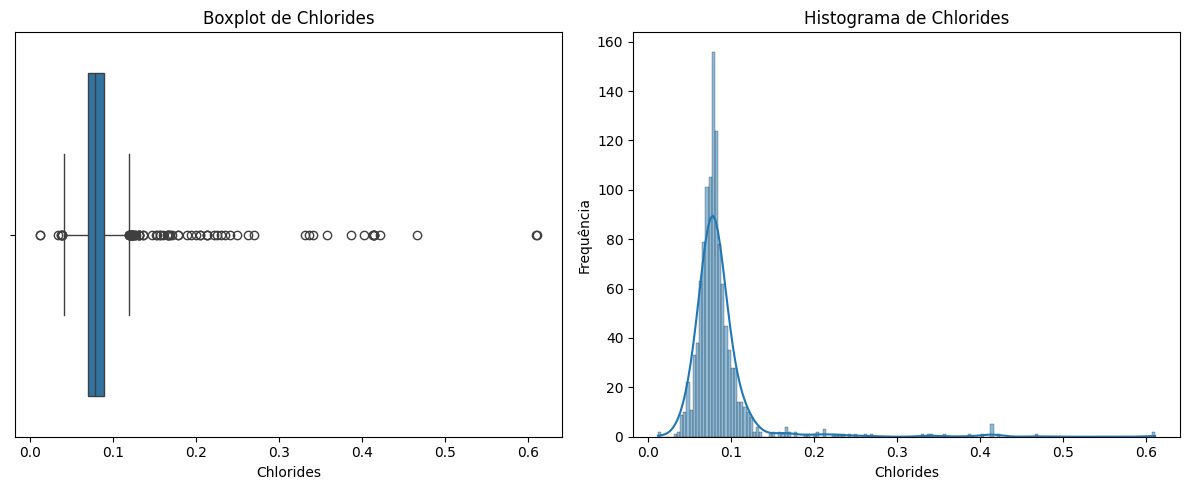

In [13]:
#Comportamento/Destribuição dos Cloretos
feature_name = 'chlorides' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

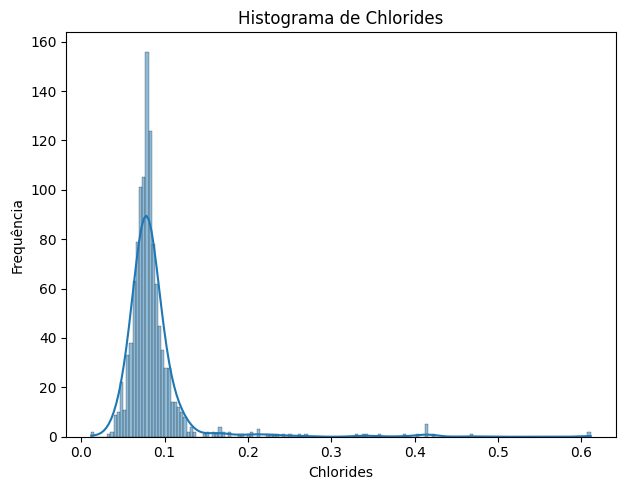

In [34]:
#Comportamento/Destribuição dos Cloretos
feature_name = 'chlorides' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

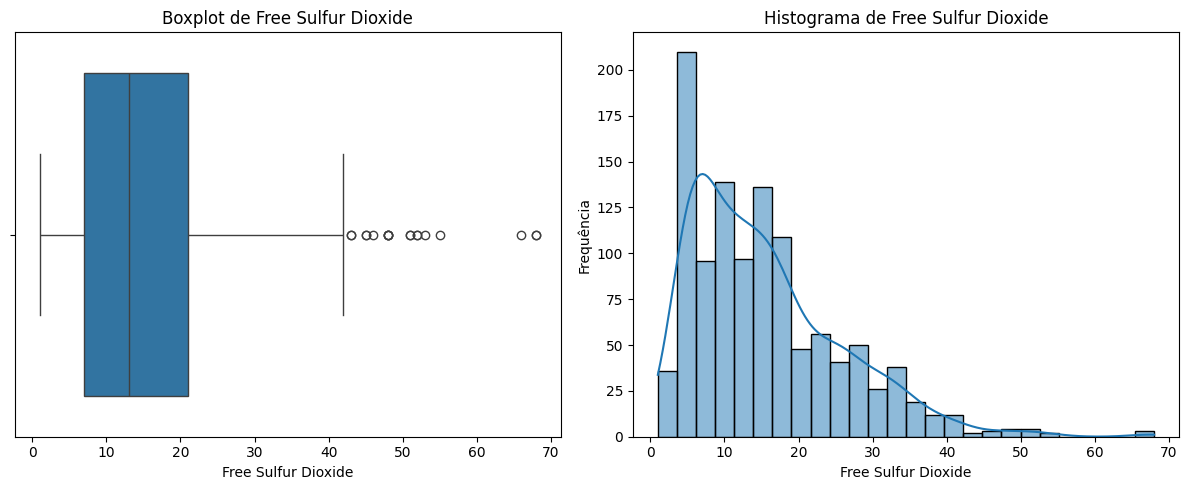

In [14]:
#Comportamento/Destribuição dos dióxidos de enxofre livres
feature_name = 'free_sulfur_dioxide' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

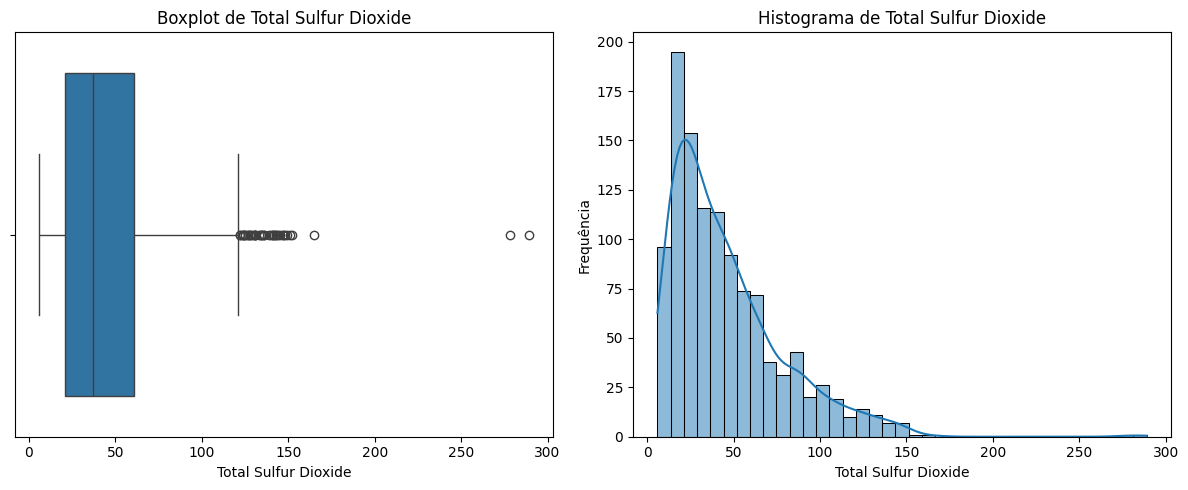

In [15]:
#Comportamento/Destribuição dos dióxidos de enxofre totais
feature_name = 'total_sulfur_dioxide' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

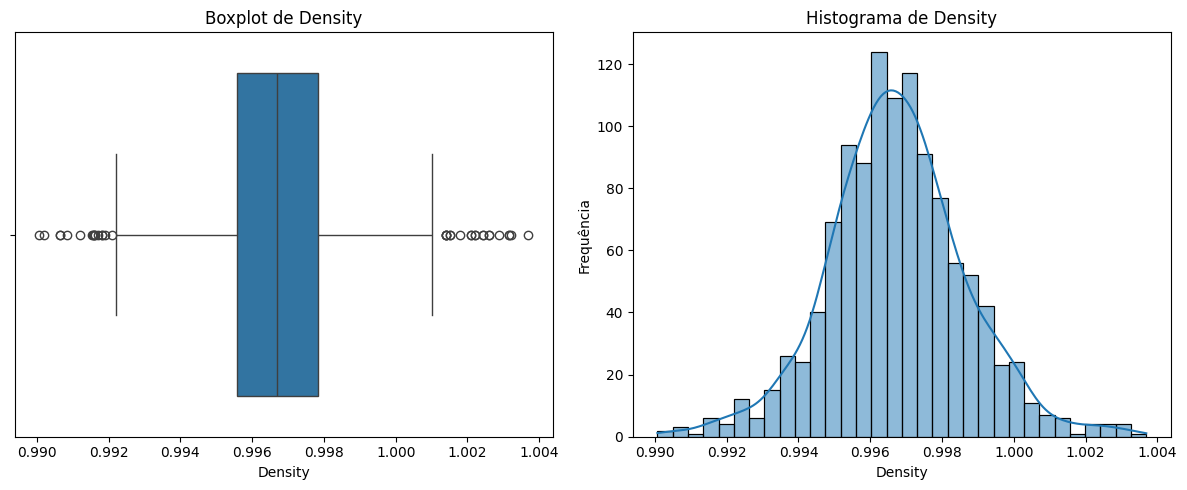

In [16]:
#Comportamento/Destribuição da Densidade
feature_name = 'density' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

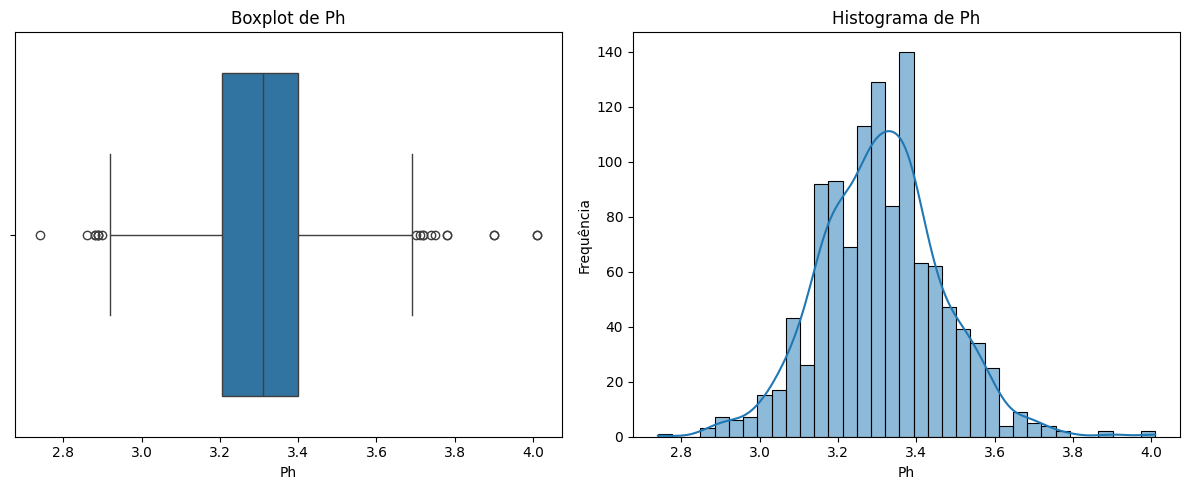

In [17]:
#Comportamento/Destribuição do pH
feature_name = 'pH' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

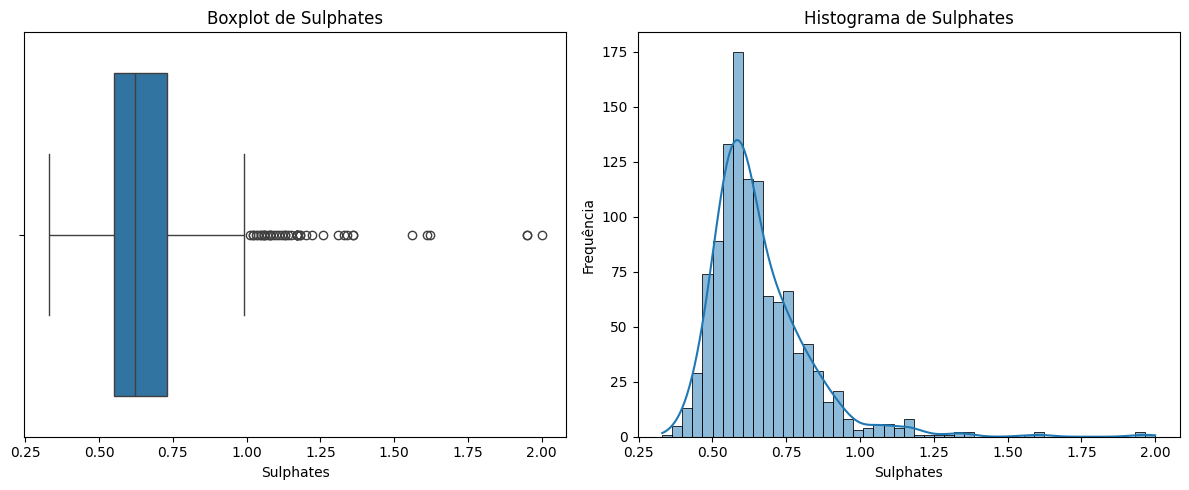

In [18]:
#Comportamento/Destribuição dos Sulfatos
feature_name = 'sulphates' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

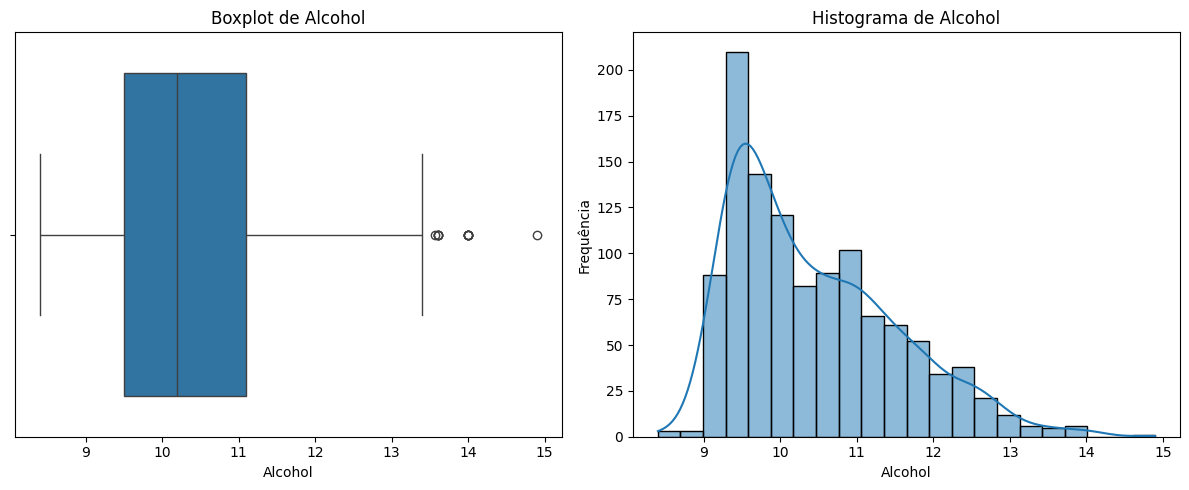

In [19]:
#Comportamento/Destribuição do Teor alcoólico
feature_name = 'alcohol' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

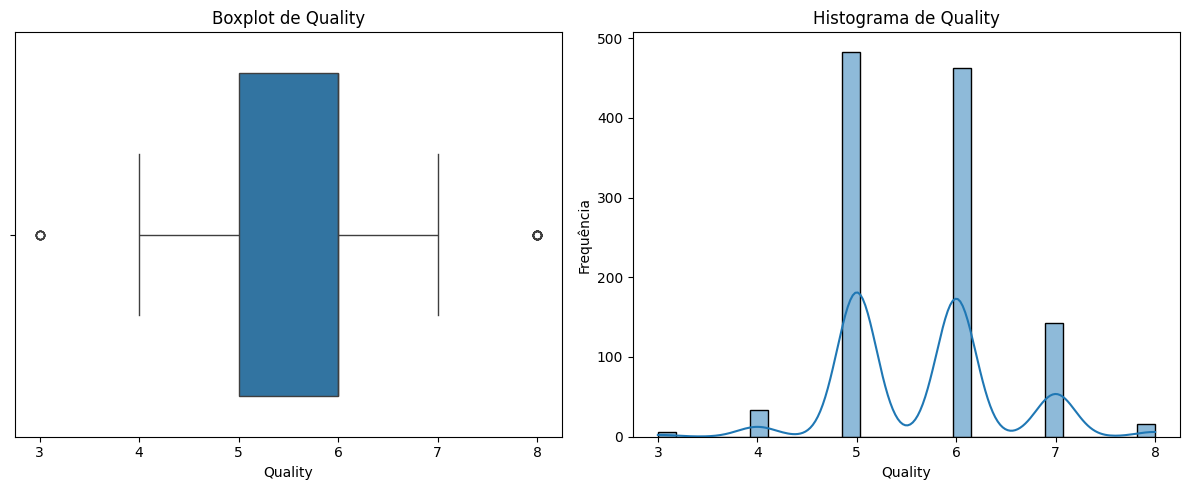

In [20]:
#Comportamento/Destribuição da Qualidade do Vinho
feature_name = 'quality' # Mude esta variável para a coluna desejada

plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro gráfico
sns.boxplot(x=df[feature_name]) # Alterado para boxplot horizontal
plt.title(f'Boxplot de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title()) # Ajuste do label
plt.ylabel('') # Removido o label Y pois o boxplot é horizontal

# Histograma
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo gráfico
sns.histplot(df[feature_name], kde=True)
plt.title(f'Histograma de {feature_name.replace("_", " ").title()}')
plt.xlabel(feature_name.replace("_", " ").title())
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

Conforme visto na análise estatística e comprovado com os gráficos, algumas das variáveis tem muitaos outliers. Vamos quantificá-los para verificar qual medida tomar (tirar da análise, substituir por alguma média ou mediana, ou algum outro método).

In [21]:
outliers = {}
for column in df.select_dtypes(include=np.number).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Contar outliers
    num_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    outliers[column] = num_outliers

outliers_df = pd.DataFrame(outliers.items(), columns=['Feature', 'Número de Outliers'])

total_samples = df.shape[0]
outliers_df['Porcentagem de Outliers'] = ((outliers_df['Número de Outliers'] / total_samples) * 100).round(2)

print("Quantidade e Porcentagem de Outliers por Coluna (IQR Method):\n")
display(outliers_df)

Quantidade e Porcentagem de Outliers por Coluna (IQR Method):



,Feature,Número de Outliers,Porcentagem de Outliers
0,fixed_acidity,44,3.85
1,volatile_acidity,14,1.22
2,citric_acid,1,0.09
3,residual_sugar,110,9.62
4,chlorides,77,6.74
5,free_sulfur_dioxide,18,1.57
6,total_sulfur_dioxide,40,3.50
7,density,36,3.15
8,pH,20,1.75
9,sulphates,43,3.76


Para entender o impacto dos outliers na qualidade do vinho, iremos calcular as média da qualidade em dois cenários, com a base cheia e excluindo os outliers, dessa forma entendos um pouco sobre a correlação. Posteriormente será avaliado a correlação de fato para verificar qual variável tem maior impacto na qualidade do vinho.

In [22]:
#Média da qualidade dos vinhos com toda a base
print(df.quality.mean().round(2))

5.66


In [23]:
#Criação de novo df retirando todos os outliers


In [24]:
#Criação de novo df retirando todos os outliers
df_cleaned = df.copy()

for column in df.select_dtypes(include=np.number).columns:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]

df_cleaned.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [25]:
#formato do df sem outliers
df_cleaned.shape

(787, 12)

Após a retirada de 356 amostras que se encaixam como outliers em cada setor, temos uma média de qualidade igual a:

In [26]:
print(df_cleaned.quality.mean().round(2))

5.63


Média df total: 5.66

Média df sem outlier: 5.63

A remoção dos outliers gerou variação de apenas 0,03 na média da variável alvo (quality), indicando que os valores extremos não parecem afetar significativamente a tendência central da qualidade. Entretanto, como os outliers estão presentes nas variáveis explicativas, ainda é necessário verificar possíveis impactos nas relações entre variáveis e na etapa de modelagem.


<Axes: >

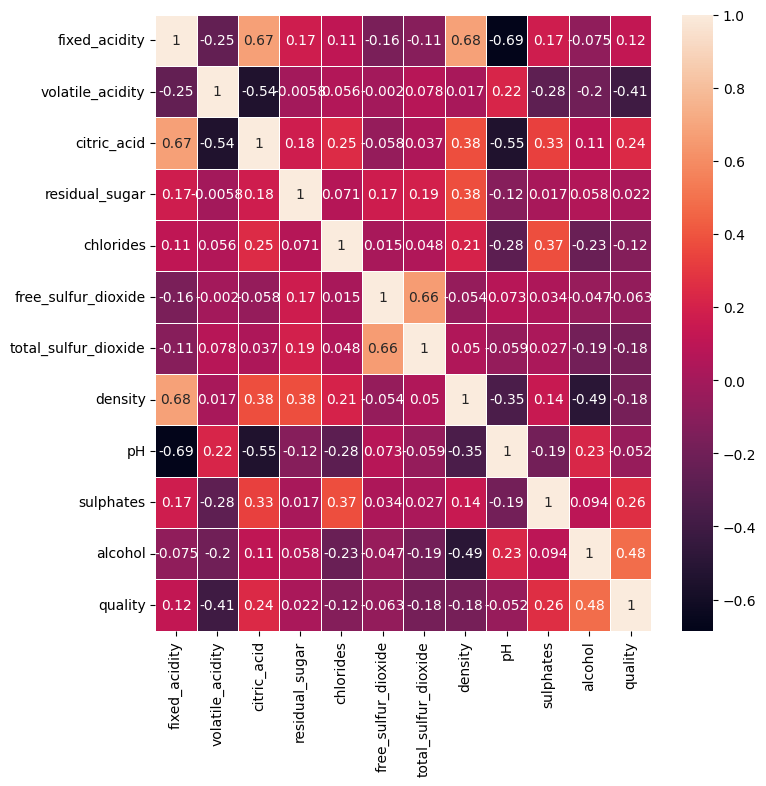

In [27]:
correlation_matrix = df.corr()

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(correlation_matrix, annot=True, linewidths=.5, ax=ax)

Através do mapa de calor vemos que as variáveis que tem maior correlação, ainda sim pequena, é o Teor Alcoólico e o ácido volátil

Verificação do comportamento da qualidade em relação ao teor alcoólico:

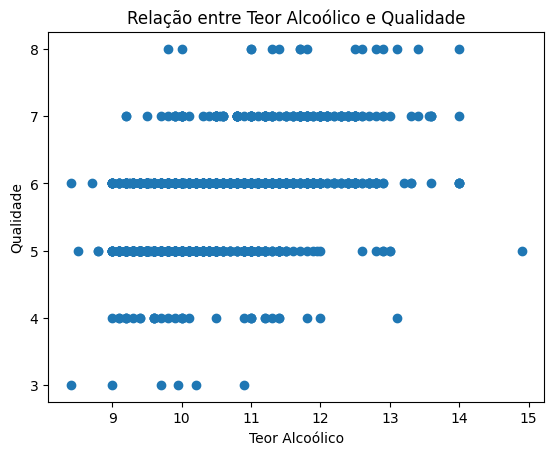

In [28]:
plt.scatter(df.alcohol, df.quality)
plt.xlabel('Teor Alcoólico')
plt.ylabel('Qualidade')
plt.title('Relação entre Teor Alcoólico e Qualidade')
plt.show()

Verificação do comportamento da qualidade em relação ao ácido volátil

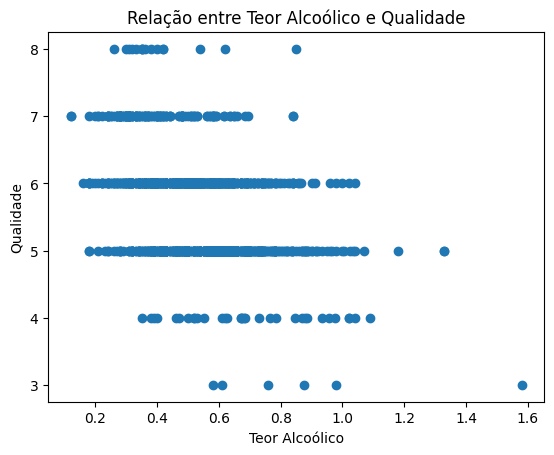

In [29]:
plt.scatter(df.volatile_acidity, df.quality)
plt.xlabel('Teor Alcoólico')
plt.ylabel('Qualidade')
plt.title('Relação entre Teor Alcoólico e Qualidade')
plt.show()

Vamos verificar a correlação das variáveis quando fazemos a classificação binária da variável alvo (qualidade):

In [30]:
# Criação da coluna quality_bin: 1 para 'alta qualidade' (quality >= 7) e 0 para 'baixa/média qualidade' (quality < 7)
df['quality_bin'] = np.where(df.quality >= 7, 1, 0)
display(df.head())

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_bin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


<Axes: >

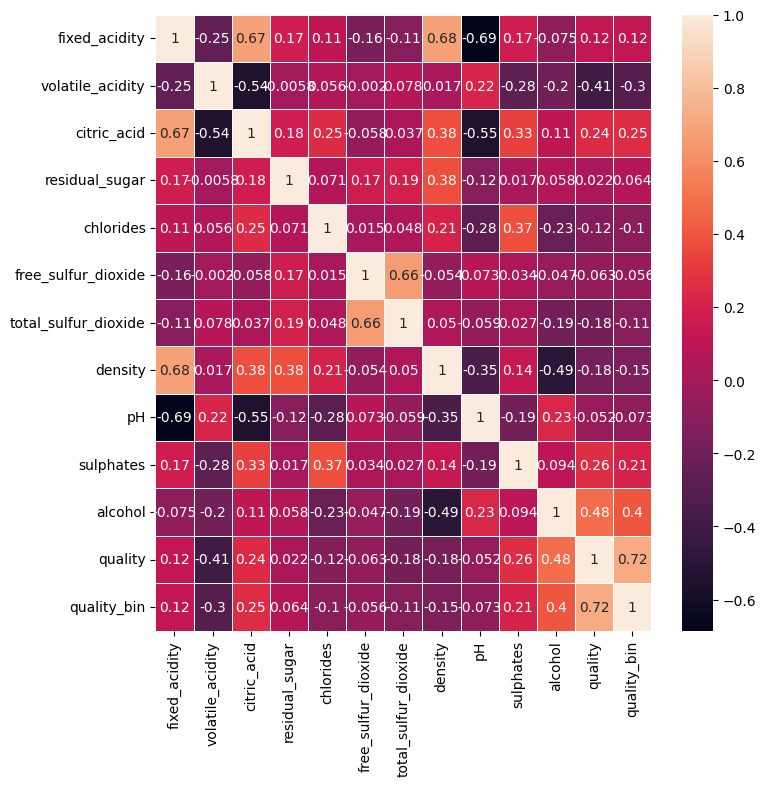

In [31]:
#Verificação da correlação de quality_bin
correlation_matrix = df.corr()

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(correlation_matrix, annot=True, linewidths=.5, ax=ax)

Novamente as variáveis com mais destaque são ácido volátil e teor alcoólico. A seguir veremos um pair plot das duas variáveis com quality_bin, para ir mais a fundo na correlação e influência de uma sobre a outra:

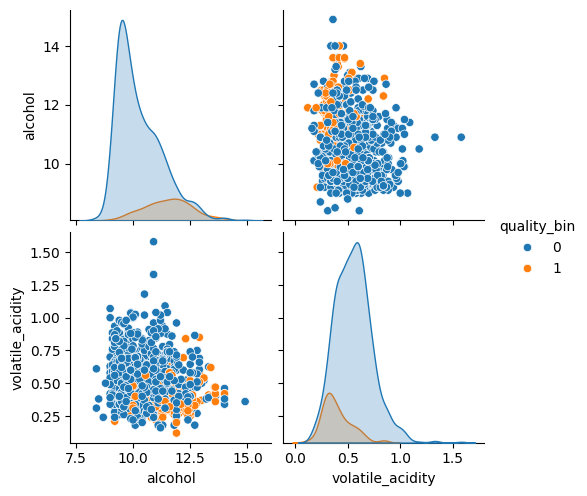

In [32]:
cols = [
'alcohol',
'volatile_acidity',
'quality_bin'
]

sns.pairplot(
    df[cols],
    hue='quality_bin'
)

Conforme visto no heatmap e corroborado pelo pairplot, a variável alcohol está diretamente correlacionada a qualidade_bin e também qualidade. Enquanto a variável volatile_acidity está inversamente correlacionada. Ou seja, quanto maior o teor aloolico, maior a qualidade e quanto menor o ácido volátil, menor a qualidade. Porém, nota-se que a distribuição das classes de qualidade ainda é muito homogênea, tendo casos de 0 e 1 em ambos os níveis de teor alcoolico e concentração de ácido volátil, com isso, não podemos afirmar que uma de define o comportamento da qualidade, e mesmo essas sendo as variáveis de maior correlação, as outras também tem influência, mesmo que não tão grande, sobre a qualidade do vinho. Dessa forma, será necessário modelos de maior complexidade para ser capaz de capturar interações entre múltiplas caracteríticas do vinho.